In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from ydata_profiling import ProfileReport
from sklearn.preprocessing import StandardScaler,LabelEncoder,OneHotEncoder,OrdinalEncoder
import warnings
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
import pickle
from sklearn.pipeline import Pipeline
%matplotlib inline
warnings.filterwarnings('ignore')

C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data=pd.read_csv('Raisin_Dataset.csv')

In [3]:
data.info

<bound method DataFrame.info of                                                   Area  MajorAxisLength  \
0                                                87524       442.246011   
1                                                75166       406.690687   
2                                                90856       442.267048   
3                                                45928       286.540559   
4                                                79408       352.190770   
..                                                 ...              ...   
896                                              87350       440.735698   
897                                              99657       431.706981   
898                                              93523       476.344094   
899                                              85609       512.081774   
900  Citation Request :\nCINAR I., KOKLU M. and TAS...              NaN   

     MinorAxisLength  Eccentricity  ConvexArea    Extent  Perimeter

In [4]:
data.head()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter,Class
0,87524,442.246011,253.291155,0.819738,90546.0,0.758651,1184.040,Kecimen
1,75166,406.690687,243.032436,0.801805,78789.0,0.684130,1121.786,Kecimen
2,90856,442.267048,266.328318,0.798354,93717.0,0.637613,1208.575,Kecimen
3,45928,286.540559,208.760042,0.684989,47336.0,0.699599,844.162,Kecimen
4,79408,352.190770,290.827533,0.564011,81463.0,0.792772,1073.251,Kecimen


In [5]:
data.describe()

,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter
count,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000
mean,430.929950,254.488133,0.781542,91186.090000,0.699508,1165.906636
std,116.035121,49.988902,0.090318,40769.290132,0.053468,273.764315
min,225.629541,143.710872,0.348730,26139.000000,0.379856,619.074000
25%,345.442898,219.111126,0.741766,61513.250000,0.670869,966.410750
50%,407.803951,247.848409,0.798846,81651.000000,0.707367,1119.509000
75%,494.187014,279.888575,0.842571,108375.750000,0.734991,1308.389750
max,997.291941,492.275279,0.962124,278217.000000,0.835455,2697.753000


In [6]:
data.Class.unique()

array(['Kecimen', 'Besni', nan], dtype=object)

<Axes: xlabel='Perimeter'>

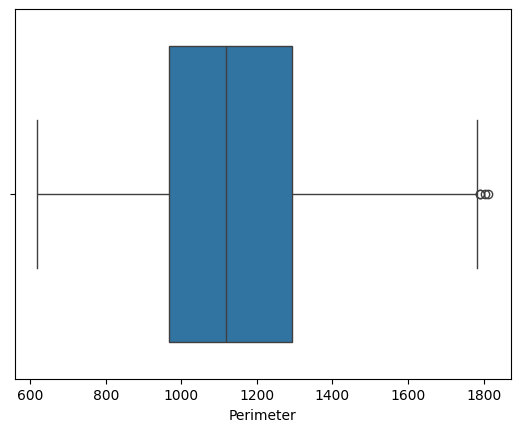

In [27]:
sns.boxplot(data=data,x='Perimeter')

In [20]:
from scipy import stats
IQR = stats.iqr(data.Perimeter, interpolation = 'midpoint') 
IQR

342.7130000000002

In [23]:
Q1 = data.Perimeter.quantile(0.25)
Q3 =data.Perimeter.quantile(0.75)
iqr = Q3-Q1
print(iqr)

341.97900000000004


In [24]:
min_limit=Q1 - 1.5*IQR
max_limit=Q3 +1.5*IQR
print("min limit = ",min_limit)
print("max limit = ",max_limit)

min limit =  452.3412499999997
max limit =  1822.4592500000003


In [26]:
data.loc[data['Perimeter'] > max_limit,'Perimeter']=np.median(data.Perimeter)

<Axes: >

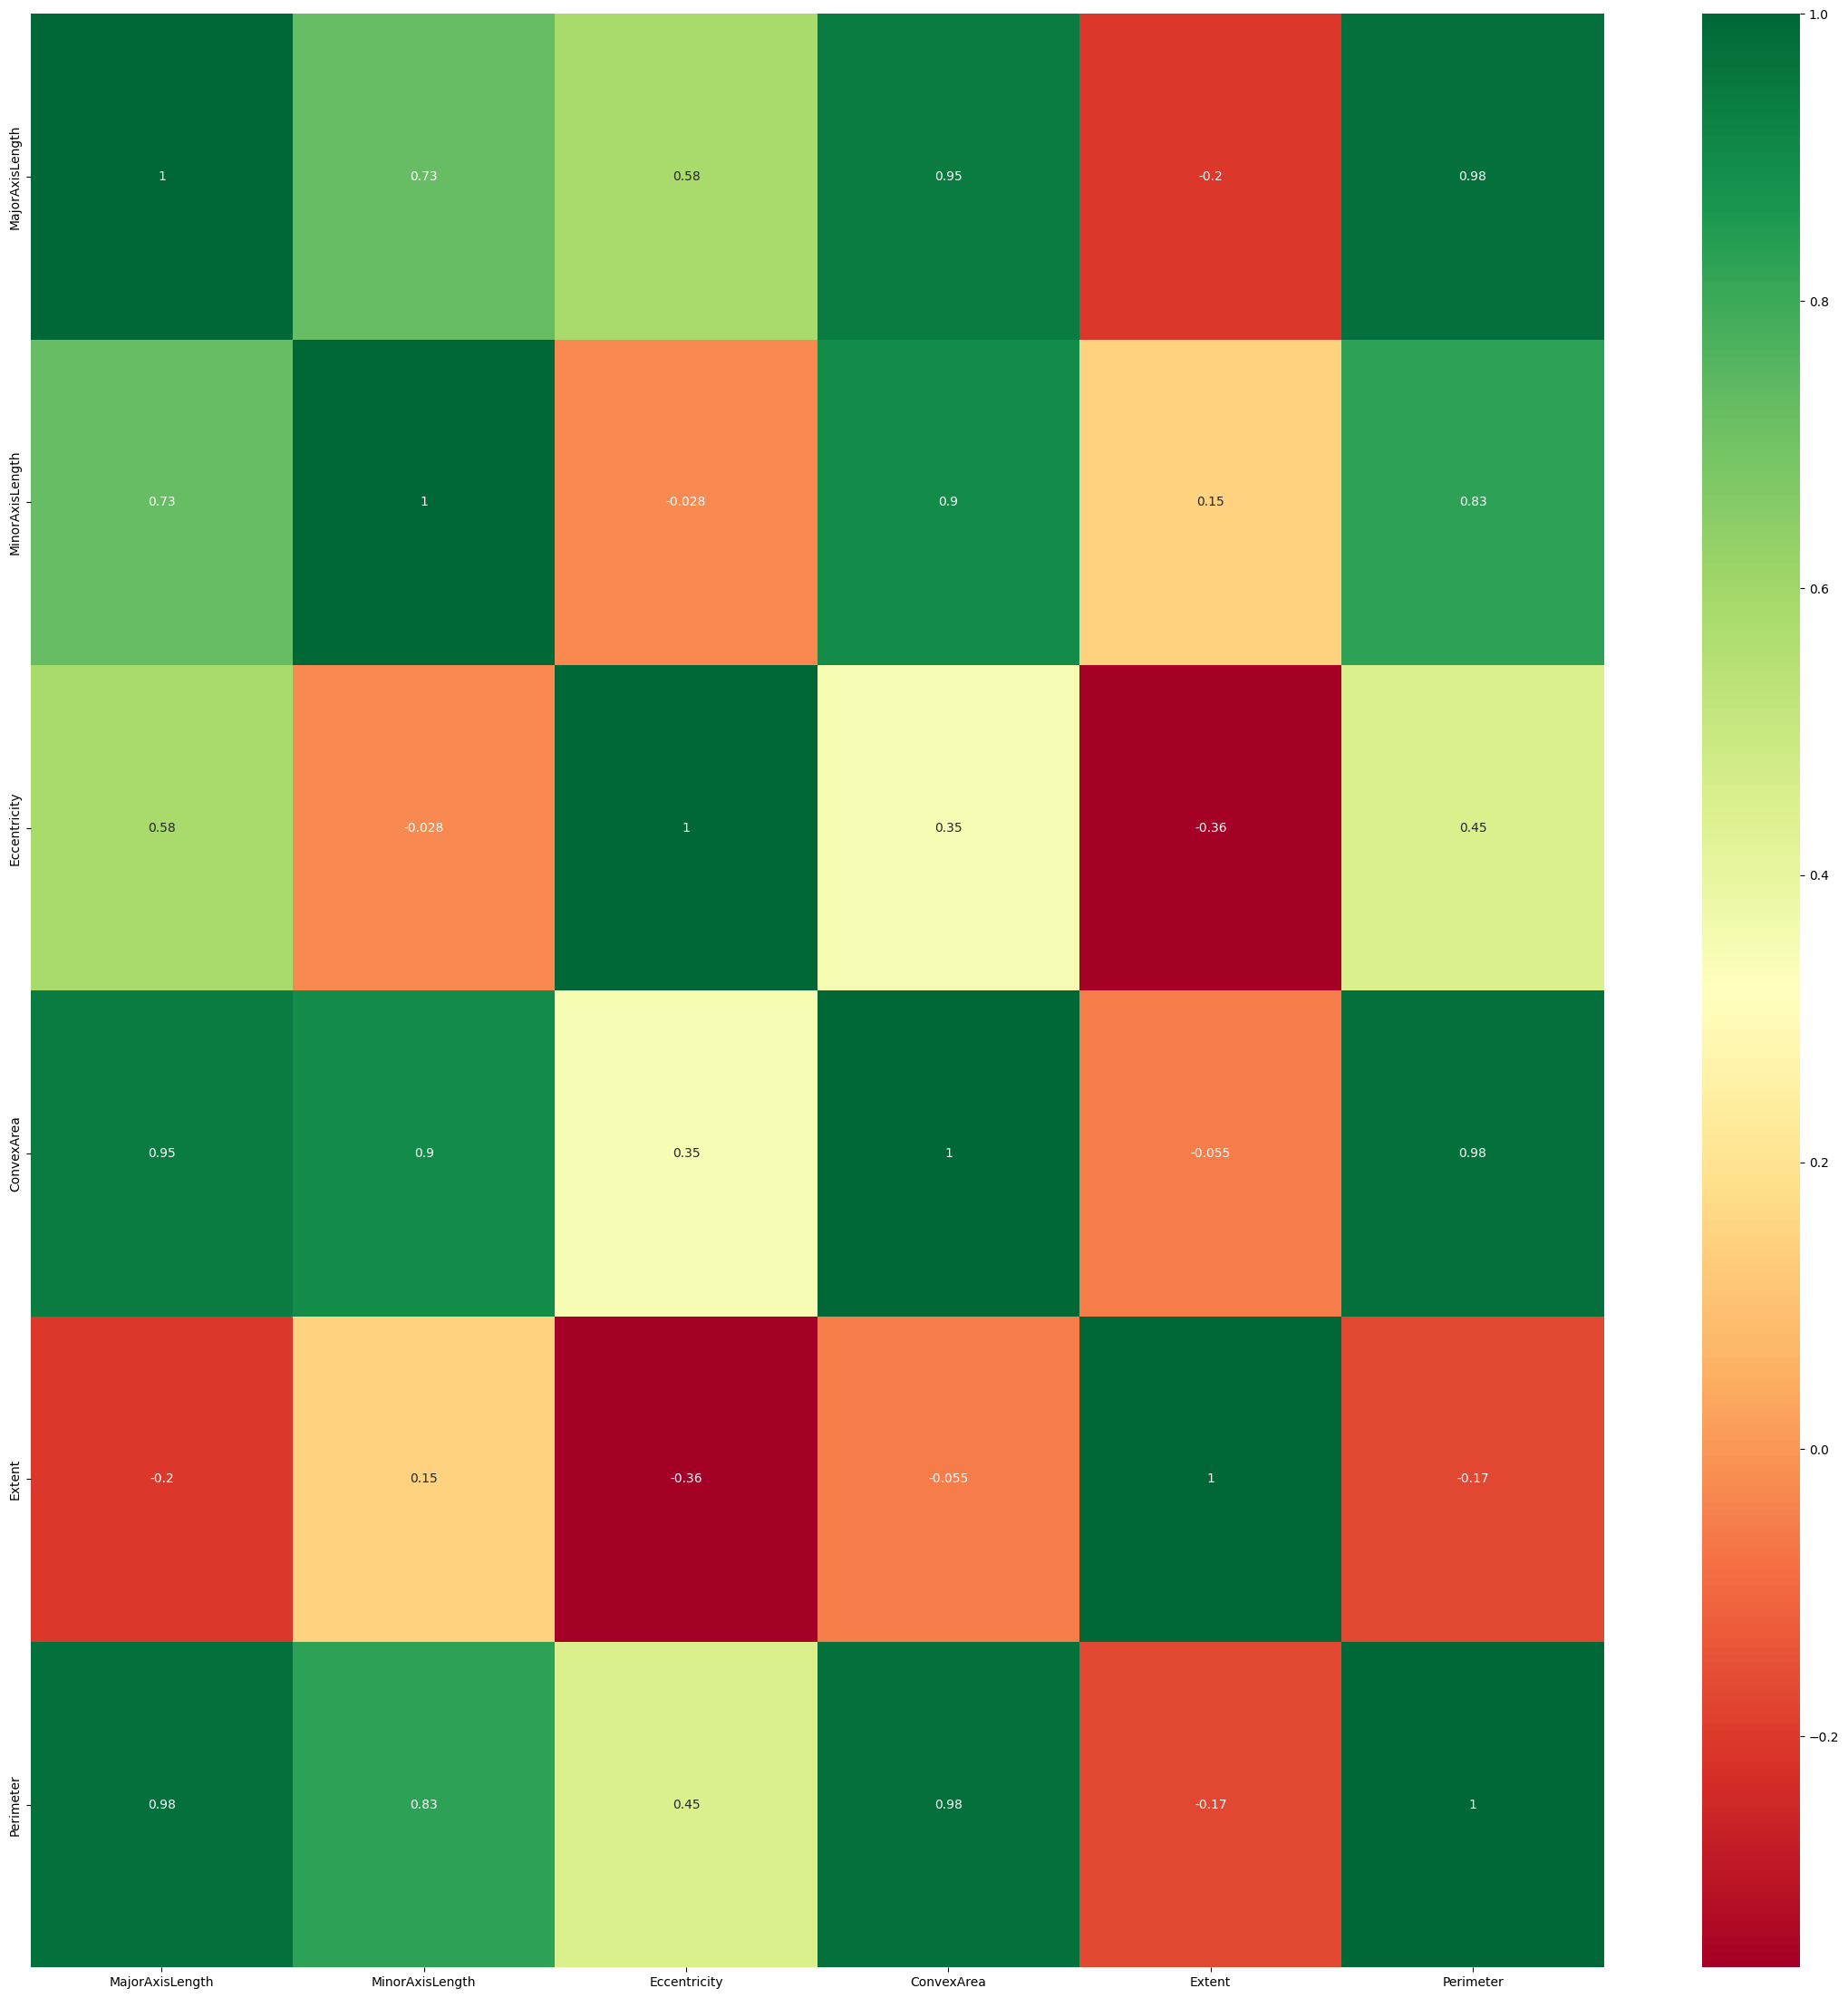

In [8]:
plt.figure(figsize=(28,28))#increase plot size
sns.heatmap(data.select_dtypes(include=['int', 'float']).corr(),cmap="RdYlGn",annot=True)

In [9]:
data.drop(columns='MajorAxisLength',inplace=True)

In [10]:
data.drop(columns='ConvexArea',inplace=True)

#Multinomial

In [13]:
data.isnull().sum()

Area               0
MinorAxisLength    0
Eccentricity       0
Extent             0
Perimeter          0
Class              0
dtype: int64

In [12]:
data.dropna(inplace=True)


In [16]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
data['Class'] = le.fit_transform(data['Class'])

In [28]:
from sklearn.naive_bayes import MultinomialNB

In [29]:
from sklearn.preprocessing import MinMaxScaler
scale=MinMaxScaler()
scale.fit_transform(data.drop(columns='Class'))


array([[0.29637031, 0.314376  , 0.7678721 , 0.83142179, 0.47337107],
       [0.23742726, 0.28494465, 0.73863618, 0.66785449, 0.42120998],
       [0.31226271, 0.35177845, 0.73300911, 0.56575414, 0.49392834],
       ...,
       [0.3542402 , 0.44504387, 0.60801693, 0.79289651, 0.56452185],
       [0.32498331, 0.31691469, 0.81025935, 0.61225439, 0.53579948],
       [0.28723648, 0.20530238, 0.91069529, 0.55347831, 0.54779283]])

In [30]:
X = data.drop('Class', axis=1)
y = data['Class']

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [34]:
model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

In [35]:
y_pred = model.predict(X_test)

In [38]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy: 0.8222222222222222

Confusion Matrix:
 [[63 23]
 [ 9 85]]

Classification Report:
               precision    recall  f1-score   support

       Besni       0.88      0.73      0.80        86
     Kecimen       0.79      0.90      0.84        94

    accuracy                           0.82       180
   macro avg       0.83      0.82      0.82       180
weighted avg       0.83      0.82      0.82       180

